<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>HW1_Q5</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# 📈 Linear Regression from Scratch
### Implementation of Gradient Descent & Normal Equation

> **Course:** Machine Learning | University of Tehran
> **Assignment:** Homework 1 - Question 5
> **Topic:** Optimization Algorithms without Libraries

---

## 📝 Problem Statement
The goal is to implement **Linear Regression** manually (using only NumPy) to predict an individual's **Income** based on two features:
1.  **Age**
2.  **Experience**

**Key Objectives:**
1.  Perform Exploratory Data Analysis (EDA).
2.  Normalize/Standardize the features (Crucial for Gradient Descent).
3.  Implement **Gradient Descent** optimization algorithm.
4.  Implement **Normal Equation** (Closed-form solution).
5.  Compare the results (MSE and learned weights).

---

### Imports

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Data

In [49]:
table = pd.read_csv('Income.csv')
table

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


### Data Overview

In [50]:
table.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [51]:
table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         20 non-null     int64
 1   experience  20 non-null     int64
 2   income      20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [52]:
table.describe()

,age,experience,income
count,20.000000,20.000000,20.000000
mean,39.650000,6.200000,40735.500000
std,10.027725,4.124382,8439.797625
min,23.000000,1.000000,27840.000000
25%,31.500000,3.750000,35452.500000
50%,40.000000,5.000000,40190.000000
75%,47.000000,9.000000,45390.000000
max,58.000000,17.000000,63600.000000


## 1. Exploratory Data Analysis (EDA)

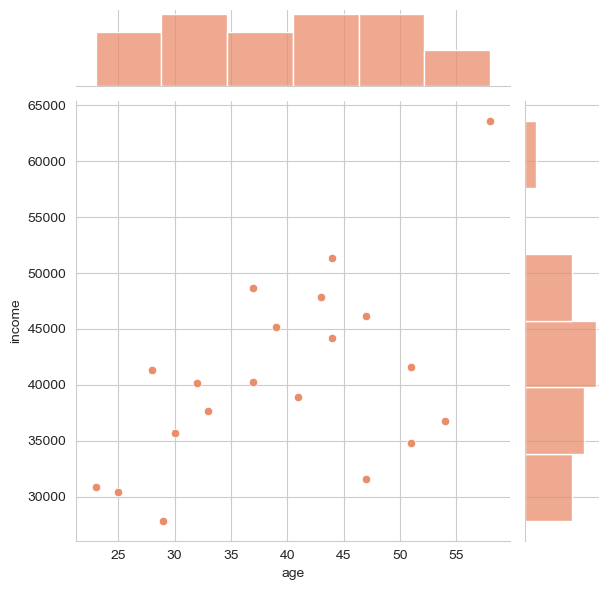

In [53]:
sns.set_palette('flare')
sns.set_style('whitegrid')
sns.jointplot(x='age',y='income',data=table)

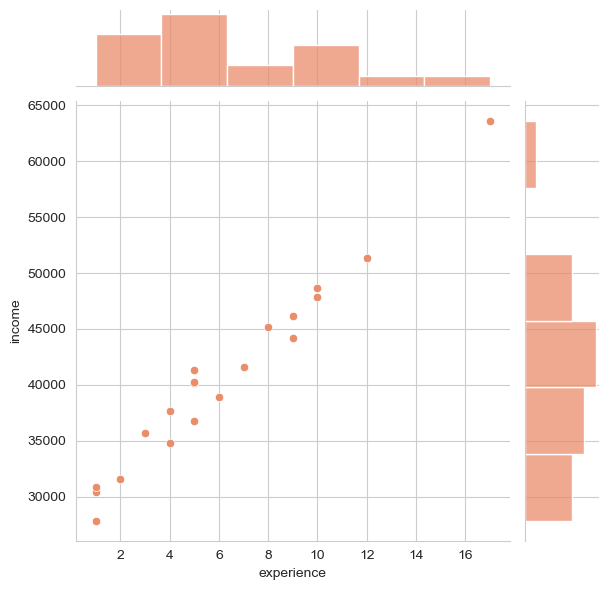

In [54]:
sns.jointplot(x='experience',y='income',data=table)

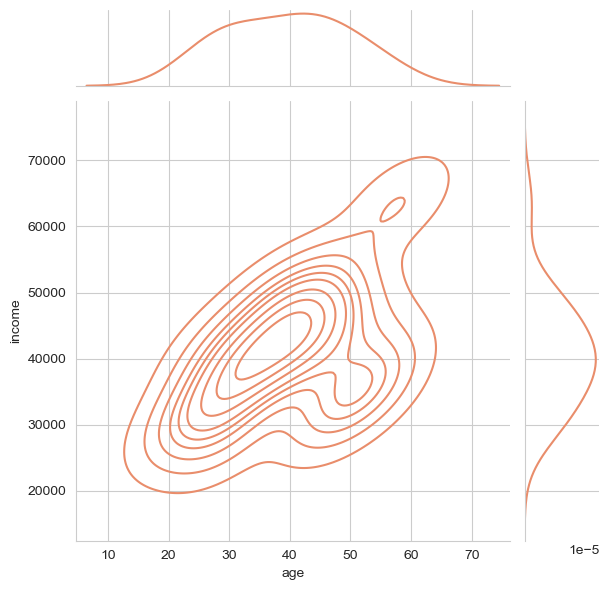

In [55]:
sns.jointplot(x='age', y='income', data=table, kind='kde')

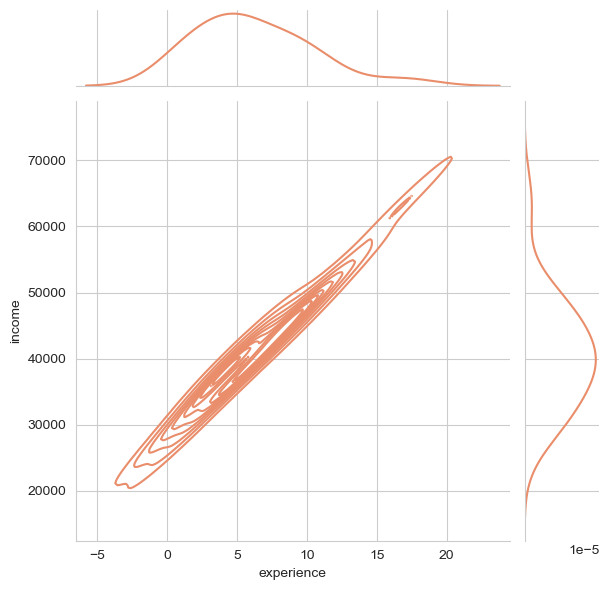

In [56]:
sns.jointplot(x='experience', y='income', data=table, kind='kde')

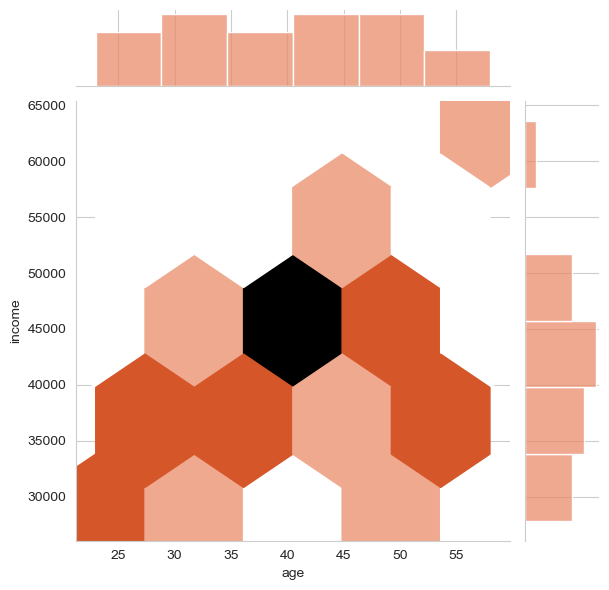

In [57]:
sns.jointplot(x='age', y='income', data=table, kind='hex')

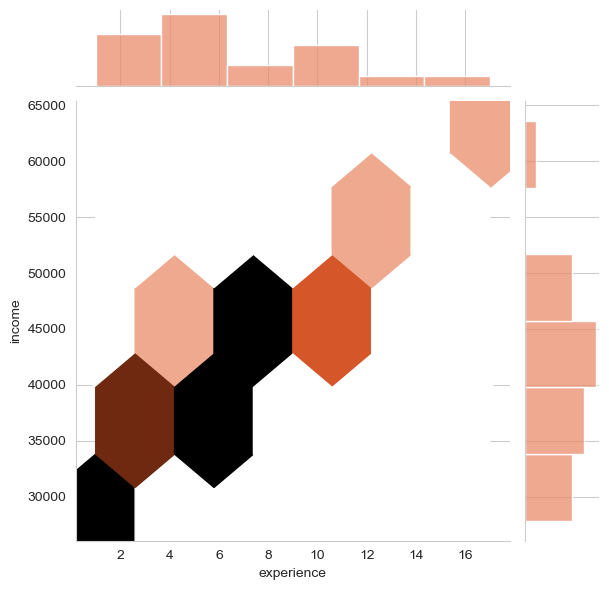

In [58]:
sns.jointplot(x='experience', y='income', data=table, kind='hex')

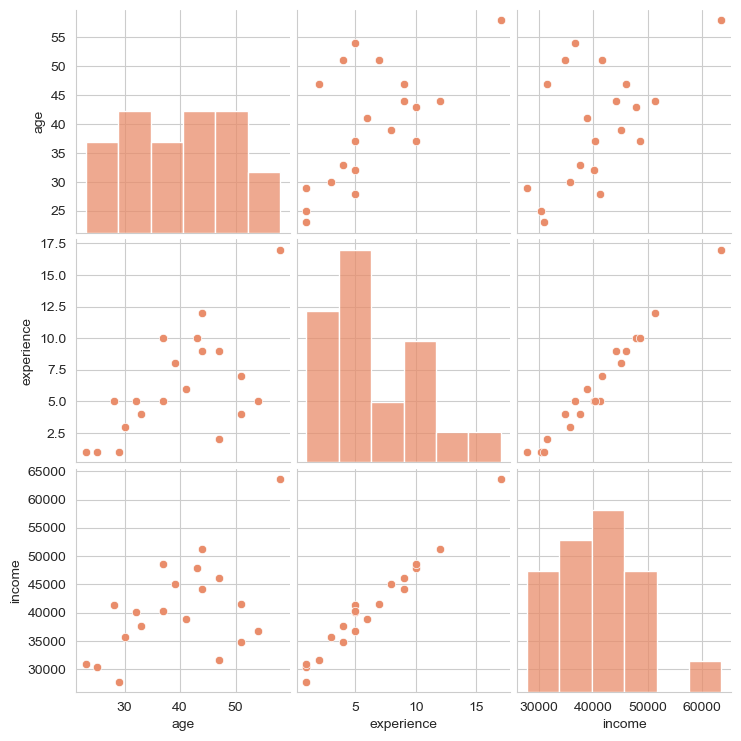

In [59]:
sns.pairplot(table)

## 2. Data Preprocessing (Normalization)

In [60]:
data_shuffled = table.sample(frac=1, random_state=42).reset_index(drop=True)
data_shuffled

,age,experience,income
0,25,1,30450
1,23,1,30870
2,41,6,38900
3,30,3,35670
4,37,5,40250
5,51,7,41630
6,47,9,46110
7,32,5,40130
8,44,9,44190
9,58,17,63600


In [61]:
train_ratio = 0.7
train_size = int(len(data_shuffled) * train_ratio)
train_data = data_shuffled[:train_size]
test_data = data_shuffled[train_size:]

In [62]:
X_train = train_data.drop(columns=['income'])
y_train = train_data['income']
X_test = test_data.drop(columns=['income'])
y_test = test_data['income']

In [63]:
X_train

,age,experience
0,25,1
1,23,1
2,41,6
3,30,3
4,37,5
5,51,7
6,47,9
7,32,5
8,44,9
9,58,17


In [64]:
y_train

0     30450
1     30870
2     38900
3     35670
4     40250
5     41630
6     46110
7     40130
8     44190
9     63600
10    34800
11    31580
12    45150
13    48700
Name: income, dtype: int64

### 2.1) Normalization:
##### Normalization, also known as Min-Max Scaling, involves scaling data to fit within a specific range, typically between 0 and 1 (or sometimes -1 to 1). The formula for normalization is:
### Xnormalized=(X−Xmin)/(Xmax−Xmin)

### 2.2) Standardization:
##### Standardization scales data to have a mean of 0 and a standard deviation of 1. This is done by transforming each value in the dataset according to this formula:
### Xstandardized=(X−μ)/σ

##### Standardization is more suitable for data that follows a normal (Gaussian) distribution. Algorithms like linear regression and support vector machines (SVMs) perform better with standardized data. We use Standardization in this Hw.

In [65]:
age_train = np.array(X_train['age'])
mu = np.mean(age_train)
sd = np.std(age_train)
age_train = (age_train - mu) / sd

experience_train = np.array(X_train['experience'])
mu = np.mean(experience_train)
sd = np.std(experience_train)
experience_train = (experience_train - mu) / sd

age_test = np.array(X_test['age'])
mu = np.mean(age_test)
sd = np.std(age_test)
age_test = (age_test - mu) / sd

experience_test = np.array(X_test['experience'])
mu = np.mean(experience_test)
sd = np.std(experience_test)
experience_test = (experience_test - mu) / sd



In [66]:
age_train

array([-1.52648402, -1.72809512,  0.08640476, -1.02245628, -0.31681744,
        1.09446024,  0.69123805, -0.82084518,  0.3888214 ,  1.80009908,
        1.09446024,  0.69123805, -0.11520634, -0.31681744])

In [67]:
experience_train

array([-1.25843366, -1.25843366, -0.05171645, -0.77574678, -0.29305989,
        0.18962699,  0.67231387, -0.29305989,  0.67231387,  2.6030614 ,
       -0.53440333, -1.01709022,  0.43097043,  0.91365731])

## 3. Implementation

In [68]:
age_train_vertical = age_train.reshape(-1, 1)
experience_train_vertical = experience_train.reshape(-1, 1)
ones_column = np.ones((len(age_train), 1))
X_m = np.hstack((ones_column, age_train_vertical ,experience_train_vertical ))
X_m


array([[ 1.        , -1.52648402, -1.25843366],
       [ 1.        , -1.72809512, -1.25843366],
       [ 1.        ,  0.08640476, -0.05171645],
       [ 1.        , -1.02245628, -0.77574678],
       [ 1.        , -0.31681744, -0.29305989],
       [ 1.        ,  1.09446024,  0.18962699],
       [ 1.        ,  0.69123805,  0.67231387],
       [ 1.        , -0.82084518, -0.29305989],
       [ 1.        ,  0.3888214 ,  0.67231387],
       [ 1.        ,  1.80009908,  2.6030614 ],
       [ 1.        ,  1.09446024, -0.53440333],
       [ 1.        ,  0.69123805, -1.01709022],
       [ 1.        , -0.11520634,  0.43097043],
       [ 1.        , -0.31681744,  0.91365731]])

In [69]:
y_v = (np.array(y_train)).reshape(-1, 1)
y_v

array([[30450],
       [30870],
       [38900],
       [35670],
       [40250],
       [41630],
       [46110],
       [40130],
       [44190],
       [63600],
       [34800],
       [31580],
       [45150],
       [48700]], dtype=int64)

In [70]:
age_test_vertical = age_test.reshape(-1, 1)
experience_test_vertical = experience_test.reshape(-1, 1)
ones_column = np.ones((len(age_test), 1))
X_m_test = np.hstack((ones_column, age_test_vertical ,experience_test_vertical ))
X_m_test


array([[ 1.        ,  0.48268187,  1.031691  ],
       [ 1.        ,  1.66257087, -0.31399291],
       [ 1.        , -0.5899445 , -0.5831297 ],
       [ 1.        , -1.01899505, -1.39054004],
       [ 1.        ,  0.5899445 ,  1.56996456],
       [ 1.        , -1.12625769, -0.31399291]])

In [71]:
y_test_v = (np.array(y_test)).reshape(-1, 1)
y_test_v

array([[47830],
       [36720],
       [37650],
       [27840],
       [51300],
       [41340]], dtype=int64)

### 3.1. Approach A: Gradient Descent

In [72]:
theta_gradient = (np.zeros(3)).reshape(-1, 1)
#alpha = 5
#alpha = 0.5
alpha = 0.05
#steps = 10
#steps = 20
#steps = 30
#steps = 40
steps = 50
for i in range(steps):
    theta_gradient = theta_gradient - alpha*( (((X_m.T) @ X_m)@theta_gradient)- (X_m.T @ y_v)  )
theta_gradient

array([[40859.28571429],
       [ -907.20976382],
       [ 8953.2049114 ]])

In [73]:
predictions_gradient = X_m_test @ theta_gradient
predictions_gradient

array([[49658.33293448],
       [36539.74229869],
       [36173.60947566],
       [29333.93803487],
       [54380.29674731],
       [39069.7947947 ]])

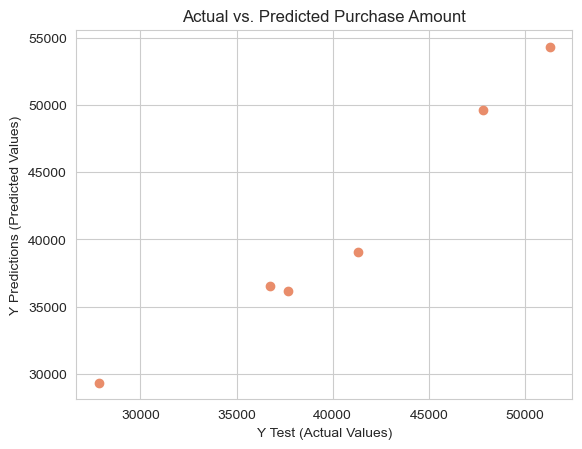

In [74]:
plt.scatter(y_test_v, predictions_gradient)
plt.xlabel('Y Test (Actual Values)')
plt.ylabel('Y Predictions (Predicted Values)')
plt.title('Actual vs. Predicted Purchase Amount')
plt.show()

In [75]:
table['income'].mean()

40735.5

In [76]:
table['income'].std()

8439.797624787483

In [77]:
MSE_gradient = (((predictions_gradient - y_test_v).T)@(predictions_gradient - y_test_v))/2
MSE_gradient

array([[11214466.85812018]])

In [78]:
RMSE_normal =  MSE_gradient**(1/2)
RMSE_normal

array([[3348.80080896]])

### 3.2. Approach B: Normal Equation

In [79]:
theta_normal = (np.linalg.inv(X_m.T @ X_m)) @ (X_m.T) @ (y_v)
theta_normal

array([[40859.28571429],
       [ -907.21536234],
       [ 8953.21050992]])

In [80]:

predictions_normal = X_m_test @ theta_normal
predictions_normal

array([[49658.33600811],
       [36539.73123286],
       [36173.60951382],
       [29333.93595477],
       [54380.30223397],
       [39069.79934218]])

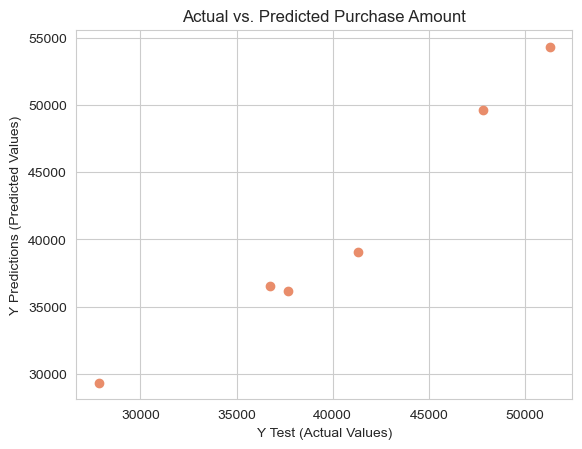

In [81]:
plt.scatter(y_test_v, predictions_normal)
plt.xlabel('Y Test (Actual Values)')
plt.ylabel('Y Predictions (Predicted Values)')
plt.title('Actual vs. Predicted Purchase Amount')
plt.show()

In [82]:
table['income'].mean()

40735.5

In [83]:
table['income'].std()

8439.797624787483

In [84]:
MSE_normal = (((predictions_normal - y_test_v).T)@(predictions_normal - y_test_v))/2
MSE_normal

array([[11214477.88550733]])

In [85]:
RMSE_normal =  MSE_normal**(1/2)
RMSE_normal

array([[3348.80245543]])